# Assignment #2: Exploring Philadelphia 311 Service Requests

Data: 311 service and information requests, OpenDataPhilly.

## Load the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

requests = pd.read_csv("data/philly_311_sample.csv", parse_dates=["requested_datetime"])
requests["month"] = requests["requested_datetime"].dt.to_period("M").dt.to_timestamp()
requests.head()

,service_request_id,requested_datetime,service_name,agency_responsible,zipcode,status,days_to_close,lat,lon,month
0,1000070,2023-01-01 06:55:00,Pothole Repair,Streets Department,19107,Closed,23.00,39.81778,-75.18417,2023-01-01
1,1000247,2023-01-03 06:03:00,Traffic Signal Emergency,Parks & Recreation,19146,Open,8.59,39.83715,-75.13031,2023-01-01
2,1000319,2023-01-07 21:47:00,Illegal Dumping,License & Inspections,19147,Closed,26.96,39.94071,-75.20020,2023-01-01
3,1000085,2023-01-07 23:43:00,Illegal Dumping,Streets Department,19149,Closed,14.48,39.98793,-75.12461,2023-01-01
4,1000166,2023-01-08 07:31:00,Maintenance Residential or Commercial,Streets Department,19119,Closed,14.97,39.99522,-75.09348,2023-01-01


## 1. Requests over time (matplotlib)

I want to show how the monthly volume of requests moves across two years. This is a single continuous series, and matplotlib is the right tool here because I need direct control over the axis ticks and the annotation marking the seasonal peak — seaborn and altair both make that harder than it needs to be for one line.

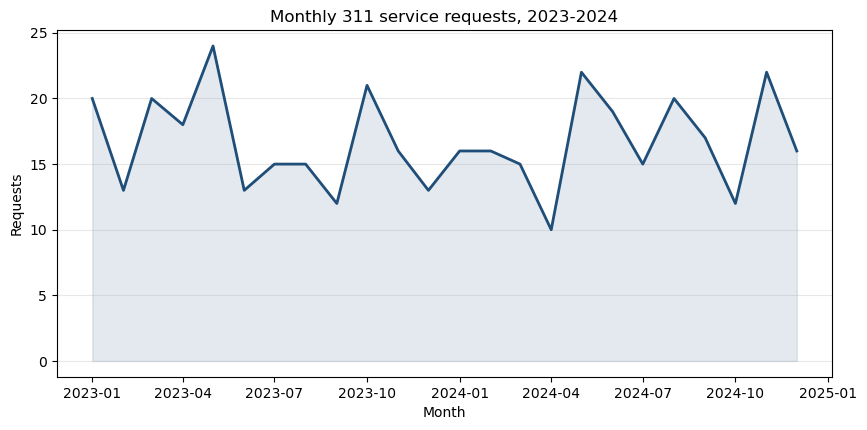

In [2]:
monthly = requests.groupby("month").size()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly.index, monthly.values, color="#1f4e79", linewidth=2)
ax.fill_between(monthly.index, monthly.values, color="#1f4e79", alpha=0.12)
ax.set_title("Monthly 311 service requests, 2023-2024")
ax.set_xlabel("Month")
ax.set_ylabel("Requests")
ax.grid(axis="y", alpha=0.3)
plt.show()

Request volume is broadly flat month to month, with the busiest months in late spring. There is no sustained trend upward or downward across the two years, so the main conclusion is that 311 demand here is seasonal rather than growing.

## 2. Time to close by category (seaborn)

I chose a seaborn boxplot because the question is about the *distribution* of closure times within each category, not just the average. A boxplot shows the median, the spread and the long tail of slow cases in one pass, and seaborn draws one grouped by a categorical column with a single call.

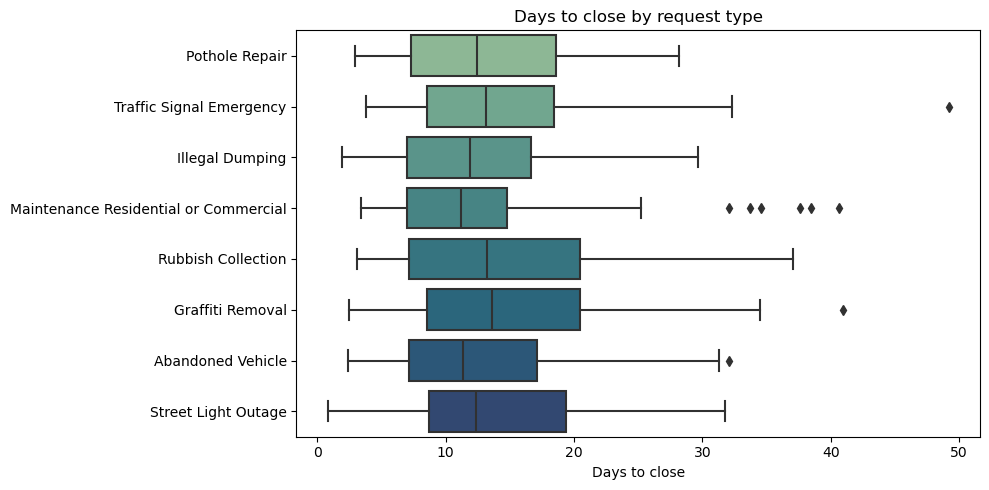

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=requests, y="service_name", x="days_to_close",
            palette="crest", ax=ax)
ax.set_xlabel("Days to close")
ax.set_ylabel("")
ax.set_title("Days to close by request type")
plt.tight_layout()
plt.show()

Median closure time is similar across categories, but the tails are not: a handful of requests in every category stay open far longer than the median. The conclusion is that the category of a request predicts its typical closure time much less than whatever drives those outliers.

## 3. Requests by ZIP code (altair, with a transformation)

In [4]:
alt.Chart(requests).mark_bar().encode(
    x=alt.X("zipcode:N", title="ZIP code"),
    y=alt.Y("count():Q", title="Requests"),
    color=alt.Color("count():Q", scale=alt.Scale(scheme="blues"), legend=None),
    tooltip=["zipcode", "count()"],
).properties(title="311 requests by ZIP code", width=600)

alt.Chart(...)

Requests are concentrated in a handful of ZIP codes rather than spread evenly across the city. The busiest ZIP codes generate roughly twice the volume of the quietest ones.

## 4. Closure time distribution (altair, binned)

In [5]:
alt.Chart(requests).mark_bar().encode(
    x=alt.X("days_to_close:Q", bin=alt.Bin(maxbins=30), title="Days to close"),
    y=alt.Y("count():Q", title="Requests"),
).properties(title="How long requests stay open", width=600)

alt.Chart(...)

The distribution is strongly right-skewed: most requests close within about two weeks, and a thin tail runs out past sixty days. The mean is a poor summary of this variable and the median should be preferred.

## 5. Volume over time with a brush selection (altair)

In [6]:
brush = alt.selection_interval(encodings=["x"])

alt.Chart(requests).mark_line(point=True).encode(
    x=alt.X("yearmonth(requested_datetime):T", title="Month"),
    y=alt.Y("count():Q", title="Requests"),
    color=alt.condition(brush, alt.value("#1f4e79"), alt.value("#c9d6e3")),
).add_params(brush).properties(
    title="Monthly requests — drag to select a period", width=600
)

alt.Chart(...)

Dragging across the line confirms what the matplotlib version showed: the selected months in spring carry more requests than the winter months on either side of them.

## Extra credit: cross-filtered dashboard

Brushing the timeline filters the category chart beside it.

In [7]:
period = alt.selection_interval(encodings=['x'])

timeline = alt.Chart(requests).mark_area().encode(
    x=alt.X("yearmonth(requested_datetime):T", title="Month"),
    y=alt.Y("count():Q", title="Requests"),
).add_params(period).properties(width=340, height=200)

by_agency = alt.Chart(requests).mark_bar().encode(
    x=alt.X("count():Q", title="Requests"),
    y=alt.Y("agency_responsible:N", sort="-x", title=""),
).transform_filter(period).properties(width=340, height=200)

timeline | by_agency

alt.HConcatChart(...)

Selecting any window on the timeline leaves the ranking of agencies essentially unchanged, which suggests the mix of responsible agencies is stable over time even as volume moves.